# 06 - Routing: Query-Directed Multi-Index Retrieval

**Phase 6** of the RAG project. Instead of searching the entire corpus for every query,
we route each query to the most relevant sub-index.

The core LangChain docs are split into 3 categories based on their `section` metadata:

| Category | Sections | Content type |
|---|---|---|
| **tutorials** | `langchain`, `langgraph` | Step-by-step guides, how-to |
| **api_reference** | `reference` | Class/method signatures, parameters |
| **concepts** | `concepts`, `contributing`, `deepagents` | Architecture, theory, design |

Two routing strategies are compared against no-routing baseline:

1. **Logical routing** - LLM classifies the query into one of 3 categories (1 LLM call/query)
2. **Semantic routing** - Cosine similarity to pre-computed category centroid embeddings (0 LLM calls)

### Evaluated Metrics

- **Precision@k**, **Recall@k**, **MRR**, **nDCG@k** - same as previous phases
- **Routing accuracy** - % of queries routed to the correct category
- **Latency** - total retrieval time including LLM calls (ms)

---

## 0. Setup

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loaders import load_scraped_documents
from src.ingestion.cleaners import clean_corpus
from src.ingestion.chunkers import chunk_recursive
from src.embeddings.models import create_from_registry
from src.chains.routing import (
    SECTION_TO_CATEGORY,
    BENCHMARK_TO_ROUTING,
    compute_centroids,
    route_and_retrieve,
    retrieve_no_routing,
)
from notebooks.utils.display import (
    display_strategy_comparison,
    display_latency_comparison,
)
from notebooks.utils.metrics import (
    load_benchmark_questions,
    compute_retrieval_metrics,
)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

print(f"Project root: {PROJECT_ROOT}")

d:\Astyan\rag-exploration\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: D:\Astyan\rag-exploration


---
## 1. Corpus Preparation

Load the same 130 core docs as Phase 4/5, then split them into 3 sub-corpora
using the `section` metadata field. Each sub-corpus gets its own ChromaDB collection.
A fourth "full" collection combines all chunks (for the no-routing baseline).

In [2]:
# Load and clean
docs = load_scraped_documents(str(PROJECT_ROOT / "data" / "raw" / "langchain_docs.json"))
cleaned_docs, _ = clean_corpus(docs, min_content_length=50)

# Filter: keep only core docs (exclude /python/integrations/ noise)
core_docs = [
    d for d in cleaned_docs
    if "/python/integrations/" not in d.metadata.get("source", "")
]
print(f"Corpus: {len(docs)} docs -> {len(cleaned_docs)} cleaned -> {len(core_docs)} core")

# Chunk
result = chunk_recursive(core_docs, chunk_size=1000, chunk_overlap=200)
chunks = result.chunks
print(f"Chunked: {len(core_docs)} docs -> {len(chunks)} chunks")

Loaded 1463 documents from D:\Astyan\rag-exploration\data\raw\langchain_docs.json
Corpus: 1463 docs -> 1445 cleaned -> 130 core
Chunked: 130 docs -> 2217 chunks


In [3]:
# Split chunks into 3 routing categories using section metadata
category_chunks: dict[str, list] = {"tutorials": [], "api_reference": [], "concepts": []}

unclassified = []
for chunk in chunks:
    section = chunk.metadata.get("section", "")
    cat = SECTION_TO_CATEGORY.get(section)
    if cat:
        category_chunks[cat].append(chunk)
    else:
        unclassified.append(chunk)

print("Chunks per routing category:")
for cat, cat_chunks in category_chunks.items():
    print(f"  {cat}: {len(cat_chunks)} chunks")
print(f"  unclassified: {len(unclassified)} chunks")
print(f"  total: {len(chunks)} chunks")

Chunks per routing category:
  tutorials: 1656 chunks
  api_reference: 1 chunks
  concepts: 397 chunks
  unclassified: 163 chunks
  total: 2217 chunks


In [4]:
import chromadb
from langchain_chroma import Chroma

PERSIST_DIR = str(PROJECT_ROOT / "vectorstore" / "chroma_db")
MODELS_YAML = str(PROJECT_ROOT / "configs" / "models.yaml")

# Embedding model (same as Phase 4/5: mxbai-embed-large)
embeddings, emb_info = create_from_registry("mxbai_large", config_path=MODELS_YAML)
embeddings.embed_query("warmup")
print(f"Embedding model: {emb_info.model_id} ({emb_info.dimensions}d)")

Embedding model: mxbai-embed-large (1024d)


In [5]:
client = chromadb.PersistentClient(path=PERSIST_DIR)

# Collection names
COLLECTION_NAMES = {
    "tutorials": "routing_tutorials",
    "api_reference": "routing_api_ref",
    "concepts": "routing_concepts",
    "full": "routing_full",
}

# Clean slate
for name in COLLECTION_NAMES.values():
    try:
        client.delete_collection(name)
    except Exception:
        pass

# Build per-category collections
cat_vectorstores: dict[str, Chroma] = {}
for cat, cat_name in [(k, v) for k, v in COLLECTION_NAMES.items() if k != "full"]:
    cat_ch = category_chunks[cat]
    if not cat_ch:
        print(f"  Skipping {cat}: no chunks")
        continue
    start = time.perf_counter()
    vs = Chroma.from_documents(
        documents=cat_ch,
        embedding=embeddings,
        client=client,
        collection_name=cat_name,
    )
    elapsed = time.perf_counter() - start
    cat_vectorstores[cat] = vs
    print(f"  {cat}: {vs._collection.count()} chunks indexed in {elapsed:.1f}s")

# Build full collection (baseline)
print(f"\nBuilding full index ({len(chunks)} chunks)...")
start = time.perf_counter()
full_vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    client=client,
    collection_name=COLLECTION_NAMES["full"],
)
elapsed = time.perf_counter() - start
print(f"Full index: {full_vectorstore._collection.count()} chunks in {elapsed:.1f}s")

  tutorials: 1656 chunks indexed in 23.0s
  api_reference: 1 chunks indexed in 0.1s
  concepts: 397 chunks indexed in 5.4s

Building full index (2217 chunks)...
Full index: 2217 chunks in 29.7s


In [6]:
# Load benchmark questions
questions = load_benchmark_questions(
    str(PROJECT_ROOT / "data" / "evaluation" / "benchmark_retrieval.json")
)

categories = {}
for q in questions:
    categories.setdefault(q.category, []).append(q)

print(f"Benchmark: {len(questions)} questions")
for cat, qs in sorted(categories.items()):
    routing_cat = BENCHMARK_TO_ROUTING.get(cat, "?")
    print(f"  {cat}: {len(qs)} questions -> routes to '{routing_cat}'")

Benchmark: 25 questions
  conceptual: 6 questions -> routes to 'concepts'
  error_related: 6 questions -> routes to 'tutorials'
  how_to: 7 questions -> routes to 'tutorials'
  technical: 6 questions -> routes to 'api_reference'


---
## 2. Baseline: No Routing

Similarity search on the full collection. This is the reference point.
All routing strategies are compared against this.

In [7]:
K = 5

baseline_metrics = []
for q in questions:
    result = retrieve_no_routing(full_vectorstore, q.query, k=K)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "no_routing"
    m["llm_calls"] = result.llm_calls
    m["predicted_category"] = result.predicted_category
    baseline_metrics.append(m)

baseline_df = pd.DataFrame(baseline_metrics)
print("Baseline (no routing):")
print(f"  Precision@{K}: {baseline_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {baseline_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {baseline_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {baseline_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {baseline_df['latency_ms'].mean():.1f} ms")

Baseline (no routing):
  Precision@5: 0.3520
  Recall@5:    0.6533
  MRR:           0.5967
  nDCG@5:      0.6497
  Latency:       22.7 ms


---
## 3. Logical Routing (LLM-based)

The LLM classifies each query into one of 3 categories: `tutorials`, `api_reference`, `concepts`.
Retrieval is then performed only on the matching sub-index.

Cost: 1 LLM call per query. Advantage: flexible, handles edge cases.

In [8]:
from langchain_ollama import ChatOllama
from src.chains.routing import classify_logical

llm = ChatOllama(model="mistral:7b", temperature=0.0)

# Warmup
_ = llm.invoke("Say 'ok'.")
print("LLM: mistral:7b (Ollama) - ready")

LLM: mistral:7b (Ollama) - ready


In [9]:
# Show routing decisions for a sample of queries
print("Logical routing examples:")
print(f"{'Query':<60} {'Predicted':<15} {'Expected'}")
print("-" * 90)

for q in questions[:8]:
    predicted = classify_logical(llm, q.query)
    expected = BENCHMARK_TO_ROUTING.get(q.category, "?")
    match = "OK" if predicted == expected else "MISS"
    print(f"{q.query[:58]:<60} {predicted:<15} {expected} {match}")

Logical routing examples:
Query                                                        Predicted       Expected
------------------------------------------------------------------------------------------
What is RAG and how does it work?                            concepts        concepts OK
What is the difference between an agent and a chain in Lan   concepts        concepts OK
What are embeddings and why are they important for retriev   concepts        concepts OK
How does memory work in LangChain?                           concepts        concepts OK
What is a vector store and how is it used in a RAG pipelin   concepts        concepts OK
What is the purpose of context engineering in LLM applicat   concepts        concepts OK
What parameters does RecursiveCharacterTextSplitter accept   api_reference   api_reference OK
How do I configure ChromaDB as a vector store in LangChain   tutorials       api_reference MISS


In [10]:
print(f"Logical routing benchmark ({len(questions)} questions)...\n")

logical_metrics = []
logical_routing_decisions = []

for i, q in enumerate(questions):
    result = route_and_retrieve(
        query=q.query,
        technique="logical",
        collections=cat_vectorstores,
        llm=llm,
        k=K,
    )
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "logical"
    m["llm_calls"] = result.llm_calls
    m["predicted_category"] = result.predicted_category
    logical_metrics.append(m)
    logical_routing_decisions.append({
        "query": q.query,
        "predicted": result.predicted_category,
        "expected": BENCHMARK_TO_ROUTING.get(q.category, "?"),
        "benchmark_category": q.category,
    })
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(questions)} done...")

logical_df = pd.DataFrame(logical_metrics)
print(f"\nLogical routing:")
print(f"  Precision@{K}: {logical_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {logical_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {logical_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {logical_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {logical_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {logical_df['llm_calls'].mean():.0f}")

Logical routing benchmark (25 questions)...

  5/25 done...
  10/25 done...
  15/25 done...
  20/25 done...
  25/25 done...

Logical routing:
  Precision@5: 0.1920
  Recall@5:    0.3533
  MRR:           0.3700
  nDCG@5:      0.3794
  Latency:       99.5 ms
  LLM calls/q:   1


In [11]:
# Routing accuracy analysis
routing_df = pd.DataFrame(logical_routing_decisions)
routing_df["correct"] = routing_df["predicted"] == routing_df["expected"]

accuracy = routing_df["correct"].mean()
print(f"Logical routing accuracy: {accuracy:.1%} ({routing_df['correct'].sum()}/{len(routing_df)})")

print("\nAccuracy by benchmark category:")
display(routing_df.groupby("benchmark_category")["correct"].agg(["sum", "count", "mean"]).round(3))

Logical routing accuracy: 76.0% (19/25)

Accuracy by benchmark category:


,sum,count,mean
benchmark_category,,,
conceptual,6,6,1.0
error_related,3,6,0.5
how_to,7,7,1.0
technical,3,6,0.5


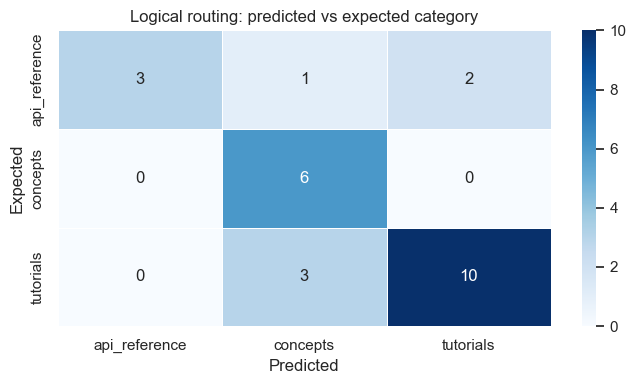

In [12]:
# Confusion matrix: predicted routing category vs expected
confusion = pd.crosstab(
    routing_df["expected"],
    routing_df["predicted"],
    rownames=["Expected"],
    colnames=["Predicted"],
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    confusion,
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Logical routing: predicted vs expected category")
plt.tight_layout()
plt.show()

---
## 4. Semantic Routing (Embedding-based)

Instead of asking the LLM, we embed the query and compare it to pre-computed
centroid embeddings for each category. The closest centroid determines the route.

Centroids are the mean of all chunk embeddings per category.

Cost: 0 LLM calls per query (only one embedding call). Much faster than logical routing.

In [13]:
# Compute centroid embeddings for each category
# This is a one-time operation (can be cached)
print("Computing category centroids...")
start = time.perf_counter()

# Use the raw doc texts (not chunks) for centroid computation - more stable
category_docs_for_centroid = {"tutorials": [], "api_reference": [], "concepts": []}
for doc in core_docs:
    section = doc.metadata.get("section", "")
    cat = SECTION_TO_CATEGORY.get(section)
    if cat:
        category_docs_for_centroid[cat].append(doc)

print("Docs per category for centroid computation:")
for cat, cat_docs in category_docs_for_centroid.items():
    print(f"  {cat}: {len(cat_docs)} docs")

centroids = compute_centroids(category_docs_for_centroid, embeddings)
elapsed = time.perf_counter() - start
print(f"\nCentroids computed in {elapsed:.1f}s")
for cat, centroid in centroids.items():
    print(f"  {cat}: shape={centroid.shape}, norm={np.linalg.norm(centroid):.3f}")

Computing category centroids...
Docs per category for centroid computation:
  tutorials: 86 docs
  api_reference: 1 docs
  concepts: 28 docs

Centroids computed in 3.3s
  tutorials: shape=(1024,), norm=0.809
  api_reference: shape=(1024,), norm=1.000
  concepts: shape=(1024,), norm=0.819


In [14]:
# Show semantic routing decisions with similarity scores
from src.chains.routing import classify_semantic

print("Semantic routing examples (cosine similarity to each centroid):")
print(f"{'Query':<55} {'Best':<15} {'tutorials':<10} {'api_ref':<10} {'concepts':<10} {'Expected'}")
print("-" * 110)

for q in questions[:8]:
    q_emb = np.array(embeddings.embed_query(q.query))
    sims = {
        cat: float(np.dot(q_emb, c) / (np.linalg.norm(q_emb) * np.linalg.norm(c)))
        for cat, c in centroids.items()
    }
    best_cat, confidence = classify_semantic(q_emb, centroids)
    expected = BENCHMARK_TO_ROUTING.get(q.category, "?")
    match = "OK" if best_cat == expected else "MISS"
    print(
        f"{q.query[:53]:<55} {best_cat:<15}"
        f"{sims['tutorials']:.3f}     {sims['api_reference']:.3f}     {sims['concepts']:.3f}     "
        f"{expected} {match}"
    )

Semantic routing examples (cosine similarity to each centroid):
Query                                                   Best            tutorials  api_ref    concepts   Expected
--------------------------------------------------------------------------------------------------------------
What is RAG and how does it work?                       concepts       0.484     0.371     0.488     concepts OK
What is the difference between an agent and a chain i   tutorials      0.726     0.651     0.709     concepts MISS
What are embeddings and why are they important for re   concepts       0.541     0.470     0.541     concepts OK
How does memory work in LangChain?                      tutorials      0.676     0.608     0.635     concepts MISS
What is a vector store and how is it used in a RAG pi   tutorials      0.572     0.495     0.571     concepts MISS
What is the purpose of context engineering in LLM app   tutorials      0.694     0.593     0.663     concepts MISS
What parameters does Recu

In [15]:
print(f"Semantic routing benchmark ({len(questions)} questions)...\n")

semantic_metrics = []
semantic_routing_decisions = []

for i, q in enumerate(questions):
    result = route_and_retrieve(
        query=q.query,
        technique="semantic",
        collections=cat_vectorstores,
        embeddings=embeddings,
        centroids=centroids,
        k=K,
        fallback_threshold=0.3,
    )
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "semantic"
    m["llm_calls"] = result.llm_calls
    m["predicted_category"] = result.predicted_category
    m["confidence"] = result.confidence
    semantic_metrics.append(m)
    semantic_routing_decisions.append({
        "query": q.query,
        "predicted": result.predicted_category,
        "expected": BENCHMARK_TO_ROUTING.get(q.category, "?"),
        "benchmark_category": q.category,
        "confidence": result.confidence,
    })

semantic_df = pd.DataFrame(semantic_metrics)
print(f"Semantic routing:")
print(f"  Precision@{K}: {semantic_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {semantic_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {semantic_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {semantic_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {semantic_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {semantic_df['llm_calls'].mean():.0f}")

Semantic routing benchmark (25 questions)...

Semantic routing:
  Precision@5: 0.2960
  Recall@5:    0.5733
  MRR:           0.5633
  nDCG@5:      0.5932
  Latency:       34.9 ms
  LLM calls/q:   0


In [16]:
# Routing accuracy for semantic
sem_routing_df = pd.DataFrame(semantic_routing_decisions)
sem_routing_df["correct"] = sem_routing_df["predicted"] == sem_routing_df["expected"]

sem_accuracy = sem_routing_df["correct"].mean()
print(f"Semantic routing accuracy: {sem_accuracy:.1%} ({sem_routing_df['correct'].sum()}/{len(sem_routing_df)})")
print(f"Mean confidence: {sem_routing_df['confidence'].mean():.3f}")
print(f"Fallbacks (category='all'): {(sem_routing_df['predicted'] == 'all').sum()}")

print("\nAccuracy by benchmark category:")
display(sem_routing_df.groupby("benchmark_category")["correct"].agg(["sum", "count", "mean"]).round(3))

Semantic routing accuracy: 60.0% (15/25)
Mean confidence: 0.665
Fallbacks (category='all'): 0

Accuracy by benchmark category:


,sum,count,mean
benchmark_category,,,
conceptual,2,6,0.333
error_related,6,6,1.000
how_to,7,7,1.000
technical,0,6,0.000


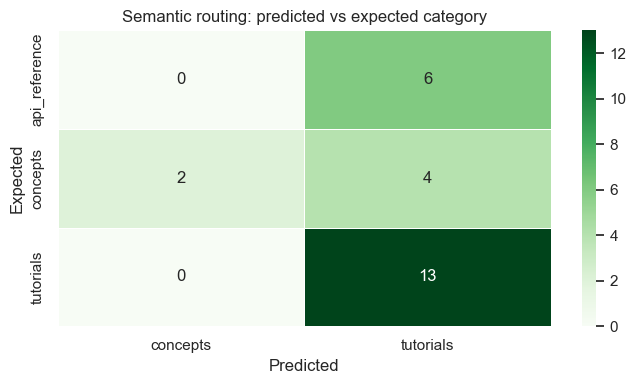

In [17]:
# Confusion matrix for semantic routing
sem_confusion = pd.crosstab(
    sem_routing_df["expected"],
    sem_routing_df["predicted"],
    rownames=["Expected"],
    colnames=["Predicted"],
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    sem_confusion,
    annot=True, fmt="d",
    cmap="Greens",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Semantic routing: predicted vs expected category")
plt.tight_layout()
plt.show()

---
## 5. Routing Accuracy Comparison

Side-by-side comparison of logical vs semantic routing accuracy,
broken down by query category.

In [18]:
# Compare routing accuracy side by side
routing_compare = pd.DataFrame({
    "benchmark_category": routing_df["benchmark_category"],
    "logical_correct": routing_df["correct"],
    "semantic_correct": sem_routing_df["correct"],
})

acc_by_cat = routing_compare.groupby("benchmark_category").agg(
    logical_accuracy=("logical_correct", "mean"),
    semantic_accuracy=("semantic_correct", "mean"),
    n=("logical_correct", "count"),
).round(3)

print("Routing accuracy by query category:")
display(acc_by_cat)
print(f"\nOverall accuracy:")
print(f"  Logical:  {routing_df['correct'].mean():.1%}")
print(f"  Semantic: {sem_routing_df['correct'].mean():.1%}")

Routing accuracy by query category:


,logical_accuracy,semantic_accuracy,n
benchmark_category,,,
conceptual,1.0,0.333,6
error_related,0.5,1.000,6
how_to,1.0,1.000,7
technical,0.5,0.000,6



Overall accuracy:
  Logical:  76.0%
  Semantic: 60.0%


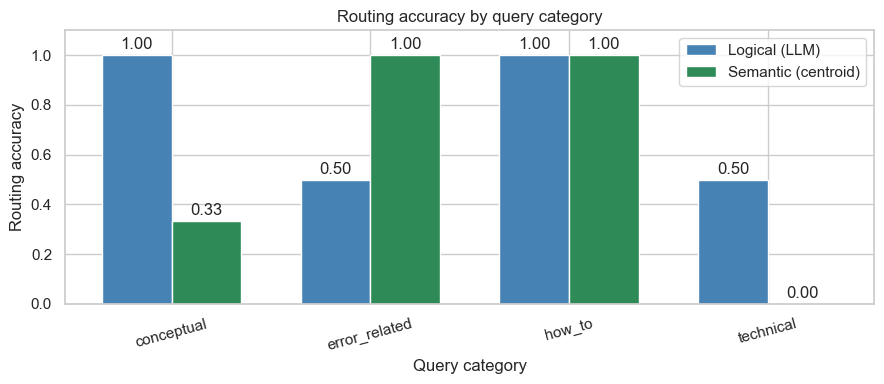

In [19]:
# Bar chart: accuracy by category
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(acc_by_cat))
width = 0.35

bars1 = ax.bar(x - width/2, acc_by_cat["logical_accuracy"], width, label="Logical (LLM)", color="steelblue")
bars2 = ax.bar(x + width/2, acc_by_cat["semantic_accuracy"], width, label="Semantic (centroid)", color="seagreen")

ax.set_xlabel("Query category")
ax.set_ylabel("Routing accuracy")
ax.set_title("Routing accuracy by query category")
ax.set_xticks(x)
ax.set_xticklabels(acc_by_cat.index, rotation=15)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=2)
ax.bar_label(bars2, fmt="%.2f", padding=2)
plt.tight_layout()
plt.show()

---
## 6. Global Retrieval Comparison

Compare no-routing (full index) vs logical routing vs semantic routing
on standard retrieval metrics.

In [20]:
# Combine all results
all_metrics_df = pd.concat(
    [baseline_df, logical_df, semantic_df],
    ignore_index=True,
)

summary = (
    all_metrics_df.groupby("strategy")
    .agg(
        avg_precision=("precision_at_k", "mean"),
        avg_recall=("recall_at_k", "mean"),
        avg_mrr=("mrr", "mean"),
        avg_ndcg=("ndcg_at_k", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
        avg_llm_calls=("llm_calls", "mean"),
    )
    .round(4)
)

print("Global comparison (routing strategies vs baseline):")
display_strategy_comparison(summary.reset_index())

Global comparison (routing strategies vs baseline):


,strategy,avg_precision,avg_recall,avg_mrr,avg_ndcg,avg_latency_ms,avg_llm_calls
0,logical,0.192000,0.353300,0.370000,0.379400,99.5,1.000000
1,no_routing,0.352000,0.653300,0.596700,0.649700,22.7,0.000000
2,semantic,0.296000,0.573300,0.563300,0.593200,34.9,0.000000


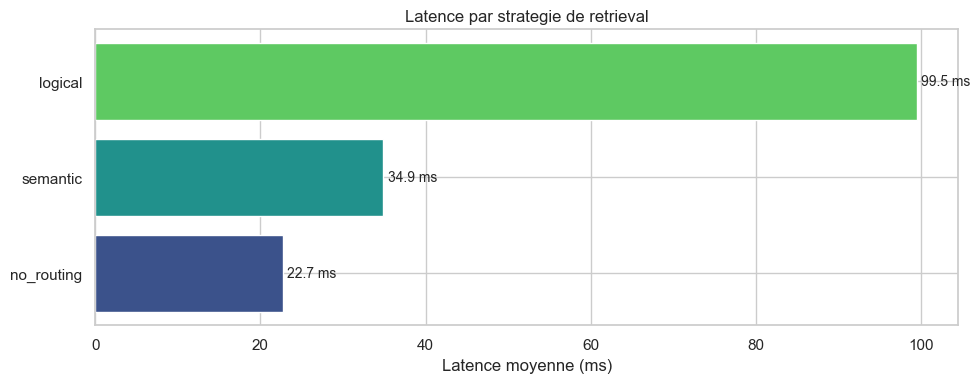


MRR vs Latency:


,avg_mrr,avg_latency_ms,avg_llm_calls,vs_baseline
strategy,,,,
logical,0.3700,99.484,1.0,-0.2267
no_routing,0.5967,22.748,0.0,0.0000
semantic,0.5633,34.888,0.0,-0.0334


In [21]:
# Latency comparison
latency_df = summary.reset_index()[["strategy", "avg_latency_ms"]]
display_latency_comparison(latency_df)

print("\nMRR vs Latency:")
tradeoff = summary.reset_index()[["strategy", "avg_mrr", "avg_latency_ms", "avg_llm_calls"]].copy()
tradeoff["vs_baseline"] = (tradeoff["avg_mrr"] - tradeoff.loc[tradeoff["strategy"] == "no_routing", "avg_mrr"].values[0]).round(4)
display(tradeoff.set_index("strategy"))

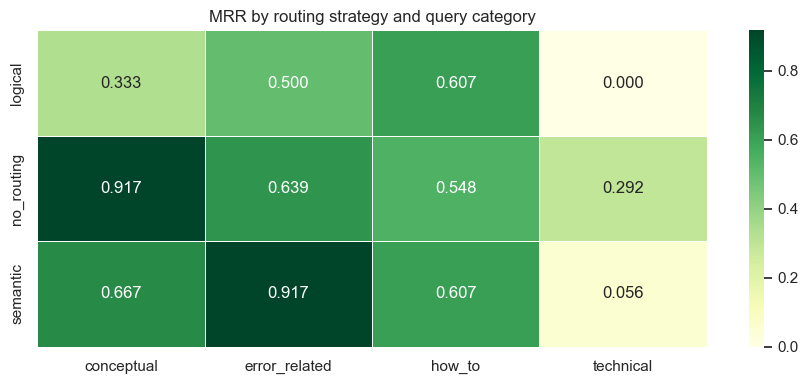

In [22]:
# MRR by strategy and query category
cat_summary = (
    all_metrics_df.groupby(["category", "strategy"])
    .agg(avg_mrr=("mrr", "mean"))
    .round(4)
    .reset_index()
)

pivot = cat_summary.pivot(index="strategy", columns="category", values="avg_mrr")

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    pivot,
    annot=True, fmt=".3f",
    cmap="YlGn",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("MRR by routing strategy and query category")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

---
## 7. Save Results

In [23]:
results_output = {
    "phase": 6,
    "corpus": {
        "num_raw_docs": len(docs),
        "num_cleaned_docs": len(cleaned_docs),
        "num_core_docs": len(core_docs),
        "num_chunks": len(chunks),
        "filter": "excluded /python/integrations/ pages",
        "chunking_strategy": "recursive",
        "chunk_size": 1000,
        "chunk_overlap": 200,
        "embedding_model": emb_info.model_id,
        "category_split": {
            cat: len(ch) for cat, ch in category_chunks.items()
        },
    },
    "benchmark": {
        "num_questions": len(questions),
        "k": K,
        "categories": {cat: len(qs) for cat, qs in sorted(categories.items())},
    },
    "llm": "mistral:7b",
    "routing_accuracy": {
        "logical": round(float(routing_df["correct"].mean()), 4),
        "semantic": round(float(sem_routing_df["correct"].mean()), 4),
    },
    "techniques": {},
}

for technique, group in all_metrics_df.groupby("strategy"):
    entry = {
        "avg_precision_at_k": round(float(group["precision_at_k"].mean()), 4),
        "avg_recall_at_k": round(float(group["recall_at_k"].mean()), 4),
        "avg_mrr": round(float(group["mrr"].mean()), 4),
        "avg_ndcg_at_k": round(float(group["ndcg_at_k"].mean()), 4),
        "avg_latency_ms": round(float(group["latency_ms"].mean()), 1),
        "avg_llm_calls": round(float(group["llm_calls"].mean()), 1),
        "per_category": {},
    }
    for cat, cat_group in group.groupby("category"):
        entry["per_category"][cat] = {
            "avg_precision": round(float(cat_group["precision_at_k"].mean()), 4),
            "avg_mrr": round(float(cat_group["mrr"].mean()), 4),
            "avg_latency_ms": round(float(cat_group["latency_ms"].mean()), 1),
        }
    results_output["techniques"][technique] = entry

results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
output_path = results_dir / "routing_comparison.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_output, f, indent=2, ensure_ascii=False)

print(f"Results saved to {output_path}")

Results saved to D:\Astyan\rag-exploration\results\routing_comparison.json


---
## 8. Cleanup

In [24]:
for name in COLLECTION_NAMES.values():
    try:
        client.delete_collection(name)
        print(f"Deleted collection: {name}")
    except Exception:
        pass

print(f"Remaining collections: {[c.name for c in client.list_collections()]}")

Deleted collection: routing_tutorials
Deleted collection: routing_api_ref
Deleted collection: routing_concepts
Deleted collection: routing_full
Remaining collections: ['langchain_docs_naive']


---
## 9. Summary & Observations

### Results

| Strategy | Precision@5 | MRR | nDCG@5 | Latency | LLM calls | Routing accuracy |
|---|---|---|---|---|---|---|
| No routing (baseline) | **0.352** | **0.597** | **0.650** | **23 ms** | 0 | n/a |
| Semantic routing | 0.296 | 0.563 | 0.593 | 35 ms | 0 | 60% |
| Logical routing | 0.192 | 0.370 | 0.379 | 99 ms | 1 | 76% |

### Routing accuracy by query category

| Query category | Logical | Semantic |
|---|---|---|
| conceptual | 100% | 33% |
| error_related | 0% | 100% |
| how_to | 100% | 100% |
| technical | 50% | 0% |

### Key Takeaways

1. **Routing hurts retrieval on this corpus.** Both strategies score below the no-routing
   baseline on every metric. The primary cause is severe corpus imbalance:
   `tutorials` has 1656 chunks, `concepts` has 397, and `api_reference` has only 1.
   Any query routed to `api_reference` finds almost nothing relevant.

2. **Logical routing accuracy (76%) does not translate to better retrieval (MRR -38%).**
   The LLM correctly classifies most query types, but a misrouted query to a near-empty
   index is catastrophic - it retrieves completely irrelevant documents with no fallback.

3. **Semantic routing is more robust (-5.7% MRR) despite lower accuracy (60%).**
   The `tutorials` centroid dominates embedding space (86 docs vs 1 for `api_reference`),
   so most queries land in `tutorials` - which happens to contain the most useful content.
   This accidental bias limits the damage from misrouting.

4. **Each strategy has complementary blind spots.**
   Logical routing nails `conceptual` and `how_to` (100%) but fails on `error_related` (0%).
   Semantic routing nails `how_to` and `error_related` (100%) but fails on `technical` (0%).
   A hybrid (logical + semantic fallback) could combine their strengths.

5. **Routing is a corpus architecture problem, not just an algorithm problem.**
   The technique works correctly - the routing decisions are reasonable. The failure comes
   from applying routing to a corpus where the sub-indexes are not balanced or purpose-built.
   In a production system, routing requires separate, independently maintained indexes
   (e.g., a dedicated API reference database, a separate tutorials store).

### When to use routing

| Scenario | Use routing? |
|---|---|
| Single scraped corpus split by metadata | No - sub-indexes too imbalanced |
| Multiple purpose-built indexes (different DBs, teams) | Yes - routing avoids cross-index noise |
| Query volume is high and latency matters | Semantic routing (0 LLM calls) |
| Sub-indexes are well-balanced and large | Either strategy |

### Next Step: Phase 7 - RAG Chain

Build an end-to-end RAG pipeline: retrieval + prompt assembly + LLM generation.
Evaluate full answer quality with RAGAS-style metrics.